In [1]:
import pyreadstat

_, meta4 = pyreadstat.read_dta(
    'C:/maternal_health_project/data/nfhs4/IAIR74FL.DTA',
    metadataonly=True
)

target_vars = ['v012','v024','v025','v106','v113','v116','v119','v130','v131',
               'v136','v137','v149','v157','v158','v159','v190','v201',
               'm14_1','v454','b5_01','v228','m15_1']

print("Checking variable presence and labels in NFHS-4 (2015-16):")
print("-"*60)
for var in target_vars:
    if var in meta4.column_names:
        label = meta4.column_names_to_labels.get(var, '')
        print(f"✅ {var}: {label}")
    else:
        print(f"❌ {var}: NOT FOUND in NFHS-4")

Checking variable presence and labels in NFHS-4 (2015-16):
------------------------------------------------------------
✅ v012: respondent's current age
✅ v024: state
✅ v025: type of place of residence
✅ v106: highest educational level
✅ v113: source of drinking water
✅ v116: type of toilet facility
✅ v119: household has: electricity
✅ v130: religion
✅ v131: caste or tribe
✅ v136: number of household members (listed)
✅ v137: number of children 5 and under in household (de jure)
✅ v149: educational attainment
✅ v157: frequency of reading newspaper or magazine
✅ v158: frequency of listening to radio
✅ v159: frequency of watching television
✅ v190: wealth index
✅ v201: total children ever born
✅ m14_1: number of antenatal visits during pregnancy
✅ v454: currently pregnant (from household questionnaire)
✅ b5_01: child is alive
✅ v228: ever had a terminated pregnancy
✅ m15_1: place of delivery


In [2]:
_, meta4_full = pyreadstat.read_dta(
    'C:/maternal_health_project/data/nfhs4/IAIR74FL.DTA',
    usecols=['v454']
)
print(f"NFHS-4 v454 value labels: {meta4_full.variable_value_labels.get('v454', 'none found')}")

NFHS-4 v454 value labels: {0: "no/don't know", 1: 'yes'}


In [3]:
import pyreadstat

label_check_vars = ['v012','v024','v025','v106','v113','v116','v119','v130','v131',
                     'v136','v137','v149','v157','v158','v159','v190','v201',
                     'm14_1','v454','b5_01','v228','m15_1']

_, meta5 = pyreadstat.read_dta('C:/maternal_health_project/data/IAIR7EFL.DTA',
                                usecols=label_check_vars, metadataonly=True)
_, meta4 = pyreadstat.read_dta('C:/maternal_health_project/data/nfhs4/IAIR74FL.DTA',
                                usecols=label_check_vars, metadataonly=True)

print(f"{'Var':<8} {'NFHS-5 label':<45} {'NFHS-4 label':<45} {'Match?'}")
print("-"*110)
for var in label_check_vars:
    l5 = meta5.column_names_to_labels.get(var, 'MISSING')
    l4 = meta4.column_names_to_labels.get(var, 'MISSING')
    match = "✅" if l5.strip().lower() == l4.strip().lower() else "⚠️ CHECK"
    print(f"{var:<8} {l5:<45} {l4:<45} {match}")

Var      NFHS-5 label                                  NFHS-4 label                                  Match?
--------------------------------------------------------------------------------------------------------------
v012     respondent's current age                      respondent's current age                      ✅
v024     state                                         state                                         ✅
v025     type of place of residence                    type of place of residence                    ✅
v106     highest educational level                     highest educational level                     ✅
v113     source of drinking water                      source of drinking water                      ✅
v116     type of toilet facility                       type of toilet facility                       ✅
v119     household has: electricity                    household has: electricity                    ✅
v130     religion                                      relig

In [4]:
import pandas as pd
import numpy as np
import pickle
import pyreadstat
import os
import warnings
warnings.filterwarnings('ignore')

NFHS4_PATH = 'C:/maternal_health_project/data/nfhs4/IAIR74FL.DTA'
NFHS5_MODEL_DIR = 'C:/maternal_health_project/models'
OUTPUT_DIR = 'C:/maternal_health_project/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("✅ Setup complete.")

✅ Setup complete.


In [5]:
_, meta4_457 = pyreadstat.read_dta(NFHS4_PATH, usecols=['v457'])
print(f"NFHS-4 v457 label: {meta4_457.column_names_to_labels.get('v457')}")
print(f"NFHS-4 v457 value labels: {meta4_457.variable_value_labels.get('v457')}")

NFHS-4 v457 label: anemia level
NFHS-4 v457 value labels: {1: 'severe', 2: 'moderate', 3: 'mild', 4: 'not anemic'}


In [6]:
with open(f'{NFHS5_MODEL_DIR}/train_test_data.pkl','rb') as f:
    d = pickle.load(f)
imp_med   = d['imputer_median']
imp_mod   = d['imputer_mode']
encoders  = d['encoders']
feature_cols = d['feature_cols']

columns_needed = [
    'v012','v024','v025','v106','v113','v116',
    'v119','v130','v131','v149','v157','v158','v159',
    'v190','b5_01','v201','v213','v228','m14_1','m15_1',
    'v437','v438','v445','v457','s116','v136','v137'
]

print("Loading NFHS-4...")
df4, meta4 = pyreadstat.read_dta(NFHS4_PATH, usecols=columns_needed)
print(f"✅ Loaded: {df4.shape[0]:,} rows")

df4_sub = df4[df4['m14_1'].notna()].copy()
print(f"Subgroup (recent births): {df4_sub.shape[0]:,} women")

# Rebuild risk_label with the SAME corrected formula used on NFHS-5
def assign_risk(row):
    anc      = row['m14_1'] if pd.notna(row['m14_1']) else 0
    anaemia  = row['v457']  if pd.notna(row['v457'])  else 4
    alive    = row['b5_01'] if pd.notna(row['b5_01']) else 1
    loss     = row['v228']  if pd.notna(row['v228'])  else 0
    delivery = row['m15_1'] if pd.notna(row['m15_1']) else 0
    wealth   = row['v190']  if pd.notna(row['v190'])  else 3
    edu      = row['v106']  if pd.notna(row['v106'])  else 1
    age      = row['v012']  if pd.notna(row['v012'])  else 25

    high_score = 0
    if anc < 2:                        high_score += 3
    if anaemia <= 2:                   high_score += 3
    if alive == 0:                     high_score += 3
    if anaemia == 1:                   high_score += 2
    if delivery == 1 and wealth <= 1:  high_score += 2
    if age < 18 or age > 40:           high_score += 1
    if wealth == 1 and edu == 0:       high_score += 1
    if loss == 1:                      high_score += 1
    return 1 if high_score >= 4 else 0

df4_sub['risk_label'] = df4_sub.apply(assign_risk, axis=1)
print("\nNFHS-4 Risk Label Distribution:")
print(df4_sub['risk_label'].value_counts())
print(f"High Risk rate: {df4_sub['risk_label'].mean()*100:.2f}%")

# Drop the same columns dropped in NFHS-5 (leakage + prior removals)
leakage_cols = ['m14_1','v457','b5_01','v228','m15_1','v213']
df4_sub = df4_sub.drop(columns=leakage_cols, errors='ignore')
df4_sub = df4_sub.drop(columns=['v001','m17_1','v453'], errors='ignore')

y_ext = df4_sub['risk_label']
X_ext_raw = df4_sub.drop(columns=['risk_label'])

# Apply SAVED imputers (transform only — fit on NFHS-5 train, never refit here)
continuous_cols  = [c for c in ['v012','v201','v437','v438','v445','v136','v137'] if c in X_ext_raw.columns]
categorical_cols = [c for c in ['v106','v113','v116','v119','v130','v131','v149',
                                 'v157','v158','v159','v190','v024','v025','s116'] if c in X_ext_raw.columns]

X_ext_imp = X_ext_raw.copy()
X_ext_imp[continuous_cols]  = imp_med.transform(X_ext_raw[continuous_cols])
X_ext_imp[categorical_cols] = imp_mod.transform(X_ext_raw[categorical_cols])

# Apply SAVED encoders (transform only, unseen categories mapped to fallback)
X_ext_enc = X_ext_imp.copy()
for col in categorical_cols:
    le = encoders[col]
    known = set(le.classes_)
    vals = X_ext_imp[col].astype(str).apply(lambda v: v if v in known else le.classes_[0])
    X_ext_enc[col] = le.transform(vals)

# Align to the EXACT feature set/order used in training
missing_in_ext = [c for c in feature_cols if c not in X_ext_enc.columns]
extra_in_ext   = [c for c in X_ext_enc.columns if c not in feature_cols]
print(f"\nFeatures missing in NFHS-4 (would need fallback): {missing_in_ext}")
print(f"Extra features in NFHS-4 (will be dropped): {extra_in_ext}")

for c in missing_in_ext:
    X_ext_enc[c] = 0  # neutral fallback — flag any of these explicitly in your limitations if non-empty

X_ext_final = X_ext_enc[feature_cols]
y_ext_arr = y_ext.values

print(f"\n✅ NFHS-4 external test set ready: {X_ext_final.shape}")

Loading NFHS-4...
✅ Loaded: 699,686 rows
Subgroup (recent births): 190,898 women

NFHS-4 Risk Label Distribution:
risk_label
0    159198
1     31700
Name: count, dtype: int64
High Risk rate: 16.61%

Features missing in NFHS-4 (would need fallback): []
Extra features in NFHS-4 (will be dropped): []

✅ NFHS-4 external test set ready: (190898, 21)


In [7]:
from sklearn.metrics import (roc_auc_score, accuracy_score, f1_score,
                             classification_report, average_precision_score)
from sklearn.utils import resample

with open(f'{NFHS5_MODEL_DIR}/xgb_model.pkl','rb') as f: xgb_pkg = pickle.load(f)
with open(f'{NFHS5_MODEL_DIR}/rf_model.pkl','rb')  as f: rf_pkg  = pickle.load(f)
with open(f'{NFHS5_MODEL_DIR}/et_model.pkl','rb')  as f: et_pkg  = pickle.load(f)
with open(f'{NFHS5_MODEL_DIR}/hgb_model.pkl','rb') as f: hgb_pkg = pickle.load(f)
with open(f'{NFHS5_MODEL_DIR}/svm_model.pkl','rb') as f: svm_pkg = pickle.load(f)
with open(f'{NFHS5_MODEL_DIR}/nb_model.pkl','rb')  as f: nb_pkg  = pickle.load(f)
with open(f'{NFHS5_MODEL_DIR}/proposed_model.pkl','rb') as f: proposed_pkg = pickle.load(f)

p_xgb = xgb_pkg['model'].predict_proba(X_ext_final)[:,1]
p_rf  = rf_pkg['model'].predict_proba(X_ext_final)[:,1]
p_et  = et_pkg['model'].predict_proba(X_ext_final)[:,1]
p_hgb = hgb_pkg['model'].predict_proba(X_ext_final)[:,1]
X_sc  = svm_pkg['scaler'].transform(X_ext_final)
p_svm = svm_pkg['model'].predict_proba(X_sc)[:,1]
p_nb  = nb_pkg['model'].predict_proba(X_ext_final)[:,1]

meta_ext = np.column_stack([p_xgb, p_rf, p_et, p_hgb, p_svm, p_nb])
w_norm = proposed_pkg['weights']
p_proposed = meta_ext @ w_norm
proposed_thresh = proposed_pkg['threshold']

def bootstrap_ci(y_true, y_prob, n_boot=2000):
    y_true = np.array(y_true); scores = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = resample(np.arange(n), n_samples=n)
        scores.append(roc_auc_score(y_true[idx], y_prob[idx]))
    scores = np.array(scores)
    return scores.mean(), np.percentile(scores,2.5), np.percentile(scores,97.5)

results = {}
models_ext = {
    'XGBoost': (p_xgb, xgb_pkg['threshold']),
    'Random Forest': (p_rf, rf_pkg['threshold']),
    'Extra Trees': (p_et, et_pkg['threshold']),
    'HistGradientBoosting': (p_hgb, hgb_pkg['threshold']),
    'SVM': (p_svm, svm_pkg['threshold']),
    'Naive Bayes': (p_nb, nb_pkg['threshold']),
    'Proposed (NNLS)': (p_proposed, proposed_thresh),
}

print("="*70)
print("  EXTERNAL VALIDATION — NFHS-4 (2015-16)")
print("="*70)
ext_results = []
for name, (prob, thresh) in models_ext.items():
    pred = (prob >= thresh).astype(int)   # reuse NFHS-5-tuned threshold, no retuning
    auc_val = roc_auc_score(y_ext_arr, prob)
    acc_val = accuracy_score(y_ext_arr, pred)
    f1_val  = f1_score(y_ext_arr, pred, average='macro')
    mean_ci, lo, hi = bootstrap_ci(y_ext_arr, prob)
    print(f"\n{name}")
    print(f"  AUC-ROC:  {auc_val:.4f}  95% CI: [{lo:.4f}, {hi:.4f}]")
    print(f"  Accuracy: {acc_val:.4f} | F1-Macro: {f1_val:.4f}")
    ext_results.append({'Model': name, 'AUC': round(auc_val,4), 'CI_low': round(lo,4),
                        'CI_high': round(hi,4), 'Accuracy': round(acc_val,4), 'F1_Macro': round(f1_val,4)})

print("\n" + classification_report(y_ext_arr, (p_proposed >= proposed_thresh).astype(int),
                                    target_names=['Not High Risk','High Risk']))

pd.DataFrame(ext_results).to_csv(f'{OUTPUT_DIR}/external_validation_nfhs4.csv', index=False)
print("\n✅ External validation results saved.")

  EXTERNAL VALIDATION — NFHS-4 (2015-16)

XGBoost
  AUC-ROC:  0.7752  95% CI: [0.7720, 0.7783]
  Accuracy: 0.8307 | F1-Macro: 0.7193

Random Forest
  AUC-ROC:  0.7794  95% CI: [0.7764, 0.7824]
  Accuracy: 0.8208 | F1-Macro: 0.7060

Extra Trees
  AUC-ROC:  0.7627  95% CI: [0.7597, 0.7658]
  Accuracy: 0.7991 | F1-Macro: 0.6791

HistGradientBoosting
  AUC-ROC:  0.7780  95% CI: [0.7750, 0.7812]
  Accuracy: 0.8435 | F1-Macro: 0.7314

SVM
  AUC-ROC:  0.7708  95% CI: [0.7678, 0.7737]
  Accuracy: 0.7803 | F1-Macro: 0.6672

Naive Bayes
  AUC-ROC:  0.7330  95% CI: [0.7297, 0.7363]
  Accuracy: 0.6823 | F1-Macro: 0.5982

Proposed (NNLS)
  AUC-ROC:  0.7775  95% CI: [0.7743, 0.7804]
  Accuracy: 0.8417 | F1-Macro: 0.7293

               precision    recall  f1-score   support

Not High Risk       0.92      0.89      0.90    159198
    High Risk       0.52      0.59      0.55     31700

     accuracy                           0.84    190898
    macro avg       0.72      0.74      0.73    190898
 weigh

In [8]:
nfhs5_ci = pd.read_csv(f'{OUTPUT_DIR}/bootstrap_ci.csv')
nfhs4_ci = pd.read_csv(f'{OUTPUT_DIR}/external_validation_nfhs4.csv')

print("Internal (NFHS-5) vs External (NFHS-4) AUC comparison:")
print("-"*70)
for _, row in nfhs4_ci.iterrows():
    match = nfhs5_ci[nfhs5_ci['Model'] == row['Model']]
    if len(match) > 0:
        internal_auc = match.iloc[0]['AUC_mean']
        print(f"{row['Model']:<28} Internal: {internal_auc:.4f}  External: {row['AUC']:.4f}  "
              f"Drop: {(internal_auc - row['AUC']):+.4f}")

Internal (NFHS-5) vs External (NFHS-4) AUC comparison:
----------------------------------------------------------------------
XGBoost                      Internal: 0.7533  External: 0.7752  Drop: -0.0219
Random Forest                Internal: 0.7349  External: 0.7794  Drop: -0.0445
Extra Trees                  Internal: 0.7173  External: 0.7627  Drop: -0.0454
HistGradientBoosting         Internal: 0.7511  External: 0.7780  Drop: -0.0269
SVM                          Internal: 0.7082  External: 0.7708  Drop: -0.0626
Naive Bayes                  Internal: 0.6842  External: 0.7330  Drop: -0.0488
Proposed (NNLS)              Internal: 0.7543  External: 0.7775  Drop: -0.0232


In [9]:
compare_cols = ['v106','v190','v012','v201']  # education, wealth, age, children ever born

print("Distribution comparison: NFHS-5 (train) vs NFHS-4 (external)")
print("-"*60)
for col in compare_cols:
    if col in X_ext_final.columns:
        print(f"\n{col}:")
        print(f"  NFHS-4 (external) value counts:\n{X_ext_final[col].value_counts(normalize=True).sort_index().round(3)}")

# Most importantly — check anaemia severity distribution directly (pre-encoding, from df4_sub before it was dropped)
# Re-derive quickly from the raw v457 read in Cell 2's dataframe, or check risk_label components
print(f"\nHigh Risk rate — NFHS-5: 16.50% | NFHS-4: {y_ext.mean()*100:.2f}%")

Distribution comparison: NFHS-5 (train) vs NFHS-4 (external)
------------------------------------------------------------

v106:
  NFHS-4 (external) value counts:
v106
0    0.289
1    0.140
2    0.466
3    0.106
Name: proportion, dtype: float64

v190:
  NFHS-4 (external) value counts:
v190
0    0.245
1    0.229
2    0.201
3    0.174
4    0.151
Name: proportion, dtype: float64

v012:
  NFHS-4 (external) value counts:
v012
15.0    0.000
16.0    0.001
17.0    0.003
18.0    0.010
19.0    0.018
20.0    0.042
21.0    0.043
22.0    0.068
23.0    0.069
24.0    0.073
25.0    0.102
26.0    0.076
27.0    0.067
28.0    0.076
29.0    0.047
30.0    0.075
31.0    0.033
32.0    0.041
33.0    0.025
34.0    0.021
35.0    0.034
36.0    0.016
37.0    0.011
38.0    0.013
39.0    0.007
40.0    0.011
41.0    0.004
42.0    0.004
43.0    0.003
44.0    0.002
45.0    0.004
46.0    0.001
47.0    0.001
48.0    0.001
49.0    0.001
Name: proportion, dtype: float64

v201:
  NFHS-4 (external) value counts:
v201
1.0   

In [10]:
with open(f'{NFHS5_MODEL_DIR}/train_test_data.pkl','rb') as f:
    d5 = pickle.load(f)
X_train5 = d5['X_train_bal']  # or use X_test if you want test-set-specific comparison

compare_cols = ['v106','v190','v012','v201']

print("Distribution comparison: NFHS-5 (train) vs NFHS-4 (external)")
print("="*60)
for col in compare_cols:
    print(f"\n--- {col} ---")
    print("NFHS-5:")
    print(X_train5[col].value_counts(normalize=True).sort_index().round(3))
    print("\nNFHS-4:")
    print(X_ext_final[col].value_counts(normalize=True).sort_index().round(3))

Distribution comparison: NFHS-5 (train) vs NFHS-4 (external)

--- v106 ---
NFHS-5:
v106
0    0.326
1    0.173
2    0.407
3    0.093
Name: proportion, dtype: float64

NFHS-4:
v106
0    0.289
1    0.140
2    0.466
3    0.106
Name: proportion, dtype: float64

--- v190 ---
NFHS-5:
v190
0    0.384
1    0.216
2    0.168
3    0.139
4    0.093
Name: proportion, dtype: float64

NFHS-4:
v190
0    0.245
1    0.229
2    0.201
3    0.174
4    0.151
Name: proportion, dtype: float64

--- v012 ---
NFHS-5:
v012
15.000000    0.0
15.185306    0.0
15.251381    0.0
15.275574    0.0
15.304889    0.0
            ... 
48.828099    0.0
48.872833    0.0
48.911424    0.0
48.966168    0.0
49.000000    0.0
Name: proportion, Length: 68961, dtype: float64

NFHS-4:
v012
15.0    0.000
16.0    0.001
17.0    0.003
18.0    0.010
19.0    0.018
20.0    0.042
21.0    0.043
22.0    0.068
23.0    0.069
24.0    0.073
25.0    0.102
26.0    0.076
27.0    0.067
28.0    0.076
29.0    0.047
30.0    0.075
31.0    0.033
32.0    0.041

In [11]:
X_test5 = d5['X_test']  # real, unresampled NFHS-5 data — use this, not X_train_bal

compare_cols = ['v106','v190','v012','v201']

print("Distribution comparison: NFHS-5 TEST (real) vs NFHS-4 (external)")
print("="*60)
for col in compare_cols:
    print(f"\n--- {col} ---")
    print("NFHS-5 (test, real):")
    print(X_test5[col].describe().round(2))
    print("\nNFHS-4 (external, real):")
    print(X_ext_final[col].describe().round(2))

Distribution comparison: NFHS-5 TEST (real) vs NFHS-4 (external)

--- v106 ---
NFHS-5 (test, real):
count    35369.00
mean         1.62
std          0.97
min          0.00
25%          1.00
50%          2.00
75%          2.00
max          3.00
Name: v106, dtype: float64

NFHS-4 (external, real):
count    190898.00
mean          1.39
std           1.01
min           0.00
25%           0.00
50%           2.00
75%           2.00
max           3.00
Name: v106, dtype: float64

--- v190 ---
NFHS-5 (test, real):
count    35369.00
mean         1.73
std          1.39
min          0.00
25%          0.00
50%          2.00
75%          3.00
max          4.00
Name: v190, dtype: float64

NFHS-4 (external, real):
count    190898.00
mean          1.76
std           1.39
min           0.00
25%           1.00
50%           2.00
75%           3.00
max           4.00
Name: v190, dtype: float64

--- v012 ---
NFHS-5 (test, real):
count    35369.00
mean        27.48
std          5.24
min         15.00
25%   

External (NFHS-4) SHAP values shape: (190898, 21)


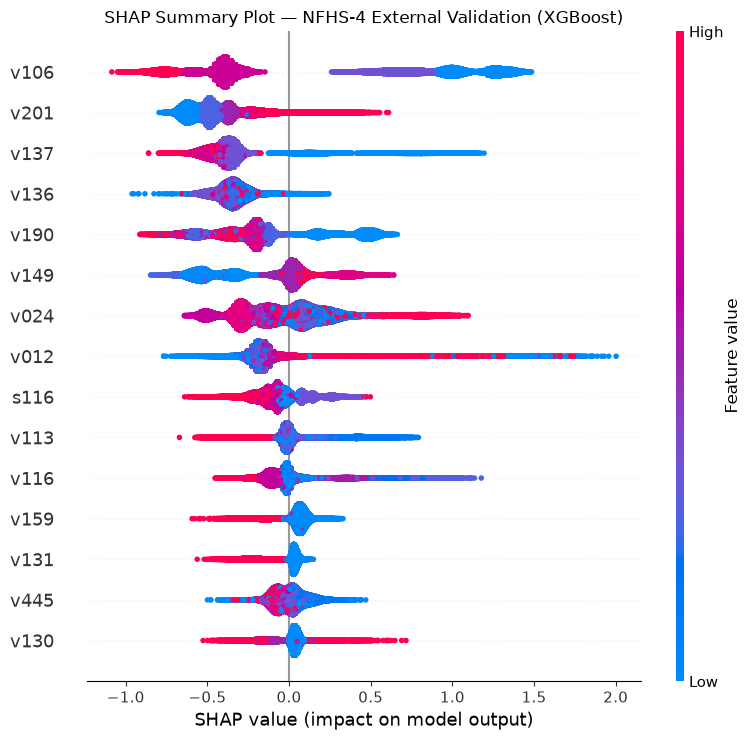

✅ External SHAP summary plot saved.


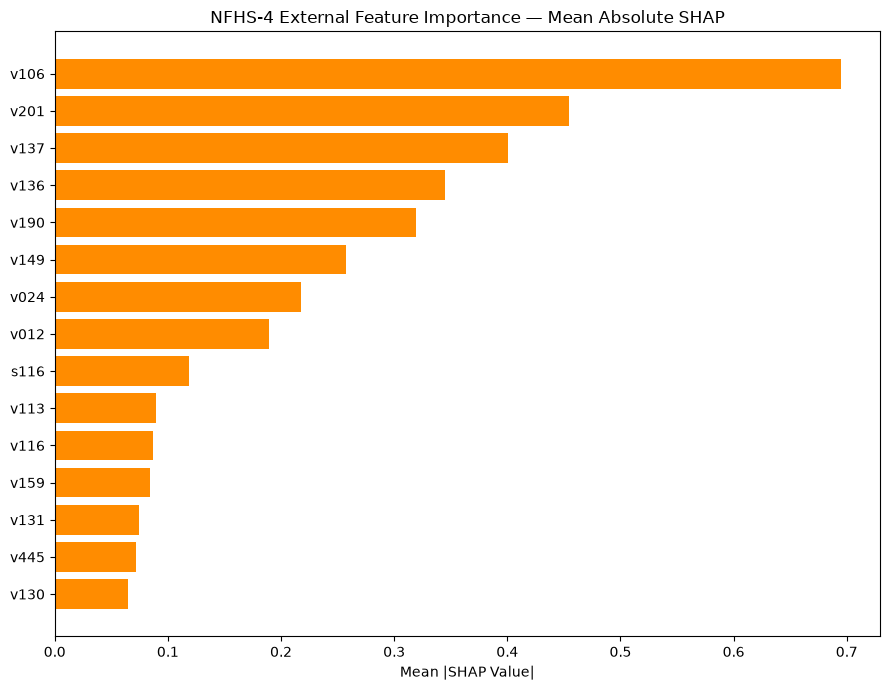

✅ External SHAP bar plot saved.

Feature ranking stability — internal (NFHS-5) vs external (NFHS-4):
feature  internal_rank  external_rank  rank_shift
   v106            1.0            1.0         0.0
   v201            2.0            2.0         0.0
   v137            3.0            3.0         0.0
   v136            4.0            4.0         0.0
   v190            5.0            5.0         0.0
   v149            6.0            6.0         0.0
   v024            7.0            7.0         0.0
   v012            8.0            8.0         0.0
   s116            9.0            9.0         0.0
   v159           10.0           12.0         2.0
   v445           11.0           14.0         3.0
   v437           12.0           16.0         4.0
   v131           13.0           13.0         0.0
   v116           14.0           11.0        -3.0
   v130           15.0           15.0         0.0
   v113           16.0           10.0        -6.0
   v025           17.0           17.0         0.0

In [12]:
import shap
import matplotlib.pyplot as plt
import os

os.makedirs('C:/maternal_health_project/figures/shap_plots_external', exist_ok=True)

# Reuse the same model SHAP was run on internally (XGBoost — justified by NNLS weight 0.643)
explainer_ext = shap.TreeExplainer(xgb_pkg['model'])
shap_values_ext = explainer_ext.shap_values(X_ext_final)

if isinstance(shap_values_ext, list):
    sv_ext = shap_values_ext[1]
elif shap_values_ext.ndim == 3:
    sv_ext = shap_values_ext[:, :, 1]
else:
    sv_ext = shap_values_ext

print("External (NFHS-4) SHAP values shape:", sv_ext.shape)

plt.figure(figsize=(10,8))
shap.summary_plot(sv_ext, X_ext_final, feature_names=list(X_ext_final.columns), max_display=15, show=False)
plt.title("SHAP Summary Plot — NFHS-4 External Validation (XGBoost)")
plt.tight_layout()
plt.savefig('C:/maternal_health_project/figures/shap_plots_external/shap_summary_nfhs4.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ External SHAP summary plot saved.")

# Bar plot
mean_shap_ext = np.abs(sv_ext).mean(axis=0)
shap_df_ext = pd.DataFrame({'feature': X_ext_final.columns, 'shap': mean_shap_ext})
shap_df_ext = shap_df_ext.sort_values('shap', ascending=True).tail(15)

plt.figure(figsize=(9,7))
plt.barh(shap_df_ext['feature'], shap_df_ext['shap'], color='darkorange')
plt.xlabel('Mean |SHAP Value|')
plt.title('NFHS-4 External Feature Importance — Mean Absolute SHAP')
plt.tight_layout()
plt.savefig('C:/maternal_health_project/figures/shap_plots_external/shap_bar_nfhs4.png', dpi=300)
plt.show()
print("✅ External SHAP bar plot saved.")

# Side-by-side ranking comparison — internal vs external
with open('C:/maternal_health_project/models/train_test_data.pkl','rb') as f:
    d5_check = pickle.load(f)
X_test5_check = d5_check['X_test']

explainer_int = shap.TreeExplainer(xgb_pkg['model'])
sv_int_check = explainer_int.shap_values(X_test5_check)
if isinstance(sv_int_check, list):
    sv_int_check = sv_int_check[1]
elif sv_int_check.ndim == 3:
    sv_int_check = sv_int_check[:, :, 1]

mean_shap_int = np.abs(sv_int_check).mean(axis=0)
rank_df = pd.DataFrame({
    'feature': X_test5_check.columns,
    'internal_shap': mean_shap_int,
    'external_shap': mean_shap_ext
}).sort_values('internal_shap', ascending=False)
rank_df['internal_rank'] = rank_df['internal_shap'].rank(ascending=False)
rank_df['external_rank'] = rank_df['external_shap'].rank(ascending=False)
rank_df['rank_shift'] = rank_df['external_rank'] - rank_df['internal_rank']

print("\nFeature ranking stability — internal (NFHS-5) vs external (NFHS-4):")
print(rank_df[['feature','internal_rank','external_rank','rank_shift']].round(1).to_string(index=False))
rank_df.to_csv('C:/maternal_health_project/outputs/shap_rank_comparison.csv', index=False)
print("\n✅ Rank comparison saved.")

In [13]:
# Recover raw wealth and state values from NFHS-4 using the SAME saved encoders
if 'v190' in encoders:
    raw_wealth_ext = encoders['v190'].inverse_transform(X_ext_final['v190'].astype(int))
else:
    raw_wealth_ext = X_ext_final['v190']

if 'v024' in encoders:
    raw_state_ext = encoders['v024'].inverse_transform(X_ext_final['v024'].astype(int))
else:
    raw_state_ext = X_ext_final['v024']

subgroup_ext = pd.DataFrame({
    'y_true': y_ext_arr,
    'wealth': raw_wealth_ext,
    'state': raw_state_ext,
    'proposed_prob': p_proposed,
})
subgroup_ext['proposed_pred'] = (subgroup_ext['proposed_prob'] >= proposed_thresh).astype(int)

subgroup_ext['wealth_numeric'] = pd.to_numeric(subgroup_ext['wealth'], errors='coerce')
subgroup_ext['state_numeric']  = pd.to_numeric(subgroup_ext['state'], errors='coerce')

print("NFHS-4 — Performance by wealth quintile (1=poorest ... 5=richest):")
print("-"*65)
wealth_results_ext = []
for wq in sorted(subgroup_ext['wealth_numeric'].dropna().unique()):
    sub = subgroup_ext[subgroup_ext['wealth_numeric'] == wq]
    if len(sub) < 50:
        continue
    n_pos = (sub['y_true']==1).sum()
    rec = ((sub['proposed_pred']==1) & (sub['y_true']==1)).sum() / max(n_pos, 1)
    prec = ((sub['proposed_pred']==1) & (sub['y_true']==1)).sum() / max((sub['proposed_pred']==1).sum(), 1)
    print(f"Wealth={wq}: n={len(sub):,} | High-Risk recall={rec:.3f} | precision={prec:.3f}")
    wealth_results_ext.append({'wealth_quintile': wq, 'n': len(sub), 'recall': round(rec,4), 'precision': round(prec,4)})

pd.DataFrame(wealth_results_ext).to_csv('C:/maternal_health_project/outputs/fairness_by_wealth_nfhs4.csv', index=False)

print("\nNFHS-4 — Performance by state (top 5 by sample size):")
print("-"*65)
state_results_ext = []
top_states_ext = subgroup_ext['state_numeric'].value_counts().head(5).index
for st in top_states_ext:
    sub = subgroup_ext[subgroup_ext['state_numeric'] == st]
    n_pos = (sub['y_true']==1).sum()
    rec = ((sub['proposed_pred']==1) & (sub['y_true']==1)).sum() / max(n_pos, 1)
    print(f"State code={st}: n={len(sub):,} | High-Risk recall={rec:.3f}")
    state_results_ext.append({'state_code': st, 'n': len(sub), 'recall': round(rec,4)})

pd.DataFrame(state_results_ext).to_csv('C:/maternal_health_project/outputs/fairness_by_state_nfhs4.csv', index=False)
print("\n✅ NFHS-4 fairness analysis saved.")

NFHS-4 — Performance by wealth quintile (1=poorest ... 5=richest):
-----------------------------------------------------------------
Wealth=1: n=46,782 | High-Risk recall=0.894 | precision=0.566
Wealth=2: n=43,739 | High-Risk recall=0.179 | precision=0.313
Wealth=3: n=38,393 | High-Risk recall=0.124 | precision=0.274
Wealth=4: n=33,212 | High-Risk recall=0.088 | precision=0.233
Wealth=5: n=28,772 | High-Risk recall=0.059 | precision=0.224

NFHS-4 — Performance by state (top 5 by sample size):
-----------------------------------------------------------------
State code=33: n=28,741 | High-Risk recall=0.546
State code=19: n=17,406 | High-Risk recall=0.658
State code=5: n=16,822 | High-Risk recall=0.780
State code=29: n=11,950 | High-Risk recall=0.515
State code=1: n=9,541 | High-Risk recall=0.727

✅ NFHS-4 fairness analysis saved.


In [14]:
wealth_int = pd.read_csv('C:/maternal_health_project/outputs/fairness_by_wealth.csv')
wealth_ext = pd.read_csv('C:/maternal_health_project/outputs/fairness_by_wealth_nfhs4.csv')

print("Wealth-quintile recall — Internal (NFHS-5) vs External (NFHS-4):")
print("-"*65)
comparison = wealth_int.merge(wealth_ext, on='wealth_quintile', suffixes=('_internal','_external'))
print(comparison[['wealth_quintile','recall_internal','recall_external']].to_string(index=False))

corr_int = wealth_int['wealth_quintile'].corr(wealth_int['recall'])
corr_ext = wealth_ext['wealth_quintile'].corr(wealth_ext['recall'])
print(f"\nWealth-recall correlation — Internal: {corr_int:.3f} | External: {corr_ext:.3f}")
print("(Similar negative correlations in both = the fairness pattern REPLICATES externally,")
print(" strengthening the claim that it's a real, generalizable phenomenon tied to label construction.)")

Wealth-quintile recall — Internal (NFHS-5) vs External (NFHS-4):
-----------------------------------------------------------------
 wealth_quintile  recall_internal  recall_external
               1           0.7522           0.8943
               2           0.1203           0.1785
               3           0.0866           0.1244
               4           0.0701           0.0880
               5           0.0438           0.0595

Wealth-recall correlation — Internal: -0.769 | External: -0.790
(Similar negative correlations in both = the fairness pattern REPLICATES externally,
 strengthening the claim that it's a real, generalizable phenomenon tied to label construction.)
